GCOPTER CSV: /home/kkondo/data/gcopter_csv/gcopter_vaj.csv
MIGHTY  CSV: /home/kkondo/data/gcopter_csv/mighty_vaj.csv


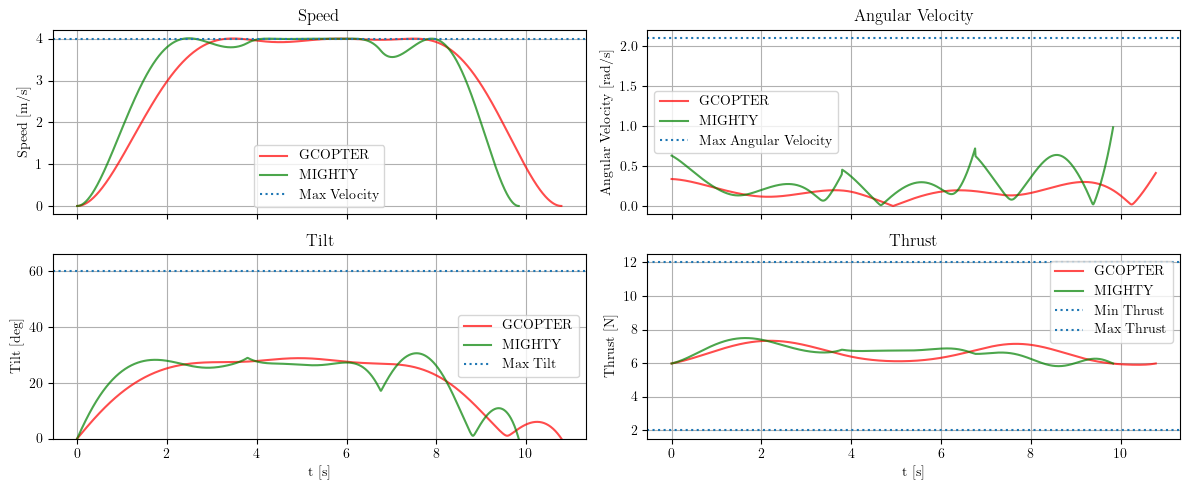

In [23]:
# Visualize one data set of GCOPTER vs MIGHTY
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
from matplotlib import font_manager

# Font settings
font = font_manager.FontProperties()
font.set_family('serif')
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = "Times New Roman"
font.set_size(40)

if True:

    def load_ros2_params(yaml_path: Path) -> dict:
        """
        Loads a ROS2 parameter YAML. Returns the 'ros__parameters' dict if present,
        otherwise the top-level dict.
        Supports these common shapes:
        1) { "/**": { "ros__parameters": {...} } }
        2) { "node": { "ros__parameters": {...} } }
        3) { "ros__parameters": {...} }
        4) flat dict of params
        """
        with open(yaml_path, "r") as f:
            y = yaml.safe_load(f)
        if not isinstance(y, dict):
            return {}
        # Try 1 & 2
        for k, v in y.items():
            if isinstance(v, dict) and "ros__parameters" in v:
                return dict(v["ros__parameters"])
        # Try 3
        if "ros__parameters" in y and isinstance(y["ros__parameters"], dict):
            return dict(y["ros__parameters"])
        # Fallback 4
        return y

    # Cell 2: helpers to extract dynamics + plotting

    def _first_col(df: pd.DataFrame, candidates):
        """Return the first present column as numpy array, else None."""
        for c in candidates:
            if c in df.columns:
                return df[c].to_numpy()
        return None

    def _norm_from_components(df, cand_x, cand_y, cand_z):
        x = _first_col(df, cand_x)
        y = _first_col(df, cand_y)
        z = _first_col(df, cand_z)
        if x is None or y is None or z is None:
            return None
        return np.sqrt(x*x + y*y + z*z)

    def extract_dyn(df: pd.DataFrame, g: float, mass: float):
        """
        Extract time histories needed for plotting:
        t, speed (|v|), omega (|ω|), tilt_rad, thrust (N)
        Falls back to compute from (a, j) if omega/tilt/thrust are not logged.
        """
        out = {}

        # time
        out["t"] = _first_col(df, ["t", "time", "sec", "timestamp"])
        if out["t"] is None:
            raise ValueError("Couldn't find a time column (t/time/sec/timestamp).")

        # speed |v|
        sp = _first_col(df, ["v_norm", "speed", "speed_norm", "|v|"])
        if sp is None:
            sp = _norm_from_components(df, ["vx"], ["vy"], ["vz"])
        out["speed"] = sp

        # body-rate |ω|
        om = _first_col(df, ["omega_norm", "om_norm", "w_norm", "|omega|", "|w|"])
        if om is None:
            # derive from a, j using b = (a + g e3)/||...||, bdot = (I - b b^T) j / ||a+ge3||
            ax = _first_col(df, ["ax"]); ay = _first_col(df, ["ay"]); az = _first_col(df, ["az"])
            jx = _first_col(df, ["jx"]); jy = _first_col(df, ["jy"]); jz = _first_col(df, ["jz"])
            if None not in (ax, ay, az, jx, jy, jz):
                nz = az + g
                r = np.sqrt(ax*ax + ay*ay + nz*nz) + 1e-12
                bx, by, bz = ax/r, ay/r, nz/r
                # P * j = j - (b·j) b
                bj = bx*jx + by*jy + bz*jz
                px = jx - bj*bx
                py = jy - bj*by
                pz = jz - bj*bz
                om = np.sqrt(px*px + py*py + pz*pz) / r
        out["omega"] = om

        # tilt (rad)
        tilt_rad = _first_col(df, ["tilt", "tilt_rad"])
        if tilt_rad is None:
            tilt_deg = _first_col(df, ["tilt_deg"])
            if tilt_deg is not None:
                tilt_rad = np.deg2rad(tilt_deg)
        if tilt_rad is None:
            # try cos(theta) or b3z
            cos_t = _first_col(df, ["cos_t", "cost", "cos_theta", "b3z", "bz"])
            if cos_t is not None:
                tilt_rad = np.arccos(np.clip(cos_t, -1.0, 1.0))
        if tilt_rad is None:
            # derive from a + g e3
            ax = _first_col(df, ["ax"]); ay = _first_col(df, ["ay"]); az = _first_col(df, ["az"])
            if None not in (ax, ay, az):
                nz = az + g
                r = np.sqrt(ax*ax + ay*ay + nz*nz) + 1e-12
                tilt_rad = np.arccos(np.clip(nz / r, -1.0, 1.0))
        out["tilt_rad"] = tilt_rad

        # thrust (N)
        thr = _first_col(df, ["thrust", "f", "T"])
        if thr is None:
            # derive from a + g e3
            ax = _first_col(df, ["ax"]); ay = _first_col(df, ["ay"]); az = _first_col(df, ["az"])
            if None not in (ax, ay, az):
                r = np.sqrt(ax*ax + ay*ay + (az + g)*(az + g))
                thr = mass * r
        out["thrust"] = thr

        return out

    def plot_overlay(gc, my,
                    V_max=None, Omega_max=None, tilt_max=None,
                    f_min=None, f_max=None,
                    tilt_units="deg", sharex=True):
        """
        One 2x2 figure overlaying GCOPTER vs MIGHTY:
        TL: |v|, TR: |ω|, BL: tilt, BR: thrust
        Draws horizontal limits when provided.
        """
        def tilt_for_plot(rad):
            if rad is None:
                return None, "Tilt"
            return (np.degrees(rad), "Tilt [deg]") if tilt_units == "deg" else (rad, "Tilt [rad]")

        tilt_gc, tilt_label = tilt_for_plot(gc["tilt_rad"])
        tilt_my, _ = tilt_for_plot(my["tilt_rad"])
        tlim = None if tilt_max is None else (np.degrees(tilt_max) if tilt_units == "deg" else tilt_max)

        fig, ax = plt.subplots(2, 2, figsize=(12, 5), sharex=sharex)
        (ax11, ax12), (ax21, ax22) = ax

        # Speed
        ax11.plot(gc["t"], gc["speed"], label="GCOPTER", color="red", alpha=0.7)
        ax11.plot(my["t"], my["speed"], label="MIGHTY", color="green", alpha=0.7)
        if V_max is not None:
            ax11.axhline(V_max, linestyle=":", label="Max Velocity")
        ax11.set_ylabel("Speed [m/s] ")
        ax11.set_title("Speed")
        ax11.grid(True); ax11.legend()

        # Body-rate
        ax12.plot(gc["t"], gc["omega"], label="GCOPTER", color="red", alpha=0.7)
        ax12.plot(my["t"], my["omega"], label="MIGHTY", color="green", alpha=0.7)
        if Omega_max is not None:
            ax12.axhline(Omega_max, linestyle=":", label="Max Angular Velocity")
        ax12.set_ylabel("Angular Velocity [rad/s]")
        ax12.set_title("Angular Velocity")
        ax12.grid(True); ax12.legend()

        # Tilt
        ax21.plot(gc["t"], tilt_gc, label="GCOPTER", color="red", alpha=0.7)
        ax21.plot(my["t"], tilt_my, label="MIGHTY", color="green", alpha=0.7)
        if tlim is not None:
            ax21.axhline(tlim, linestyle=":", label="Max Tilt")
        ax21.set_xlabel("t [s]")
        ax21.set_ylabel(tilt_label)
        ax21.set_title("Tilt") 
        if tilt_gc is not None and tilt_my is not None:
            ymax = np.nanmax([np.nanmax(tilt_gc), np.nanmax(tilt_my), (tlim if tlim is not None else 0)])
            ax21.set_ylim([0, max(1e-6, 1.1*ymax)])
        ax21.grid(True); ax21.legend()

        # Thrust
        ax22.plot(gc["t"], gc["thrust"], label="GCOPTER", color="red", alpha=0.7)
        ax22.plot(my["t"], my["thrust"], label="MIGHTY", color="green", alpha=0.7)
        if f_min is not None:
            ax22.axhline(f_min, linestyle=":", label="Min Thrust")
        if f_max is not None:
            ax22.axhline(f_max, linestyle=":", label="Max Thrust")
        ax22.set_xlabel("t [s]")
        ax22.set_ylabel("Thrust [N]")
        ax22.set_title("Thrust")
        ax22.grid(True); ax22.legend()

        fig.tight_layout()
        return fig


    def plot_history(export_dir=None, max_vel=None):

        # Cell 3: configure paths, load data, plot

        # --- paths (edit if needed) ---
        yaml_path = Path("/home/kkondo/code/gcopter_ws/src/GCOPTER/gcopter/config/global_planning.yaml")   # <- set this
        # If you want to force specific CSVs, set these; otherwise we’ll use ExportCSVDir from YAML
        gc_csv_override = None  # e.g., Path("/home/kkondo/data/gcopter_csv/gcopter_vaj.csv")
        my_csv_override = None  # e.g., Path("/home/kkondo/data/gcopter_csv/mighty_vaj.csv")

        # --- load params from YAML ---
        params = load_ros2_params(yaml_path)

        if export_dir is None:
            export_dir = Path(params.get("ExportCSVDir", "/home/kkondo/data/gcopter_csv"))
            gc_csv = gc_csv_override if gc_csv_override is not None else (export_dir / "gcopter_vaj.csv")
            my_csv = my_csv_override if my_csv_override is not None else (export_dir / "mighty_vaj.csv")
        else:
            # --- CSV paths (override if provided above) ---
            gc_csv = gc_csv_override if gc_csv_override is not None else (export_dir + "/gcopter_vaj.csv")
            my_csv = my_csv_override if my_csv_override is not None else (export_dir + "/mighty_vaj.csv")

        if max_vel is None:
            V_max      = params.get("MaxVelMag", None)
        else:
            V_max = max_vel
        Omega_max  = params.get("MaxBdrMag", None)
        tilt_max   = params.get("MaxTiltAngle", None)  # YAML already in radians
        f_min      = params.get("MinThrust", None)
        f_max      = params.get("MaxThrust", None)
        mass       = params.get("VehicleMass", 1.0)
        g          = params.get("GravAcc", 9.81)
        crop_common_time = False

        print("GCOPTER CSV:", gc_csv)
        print("MIGHTY  CSV:", my_csv)

        gc_df = pd.read_csv(gc_csv)
        my_df = pd.read_csv(my_csv)

        # --- extract dynamics using mass, g from YAML ---
        gc = extract_dyn(gc_df, g=g, mass=mass)
        my = extract_dyn(my_df, g=g, mass=mass)

        # Optional: crop both to common max time
        if crop_common_time:
            tmax = min(np.max(gc["t"]), np.max(my["t"]))
            sel_gc = gc["t"] <= tmax
            sel_my = my["t"] <= tmax
            for k in gc.keys():
                if gc[k] is not None:
                    gc[k] = gc[k][sel_gc]
            for k in my.keys():
                if my[k] is not None:
                    my[k] = my[k][sel_my]

        # --- plot (tilt in degrees is usually nicer) ---
        fig = plot_overlay(
            gc, my,
            V_max=V_max, Omega_max=Omega_max,
            tilt_max=tilt_max, f_min=f_min, f_max=f_max,
            tilt_units="deg", sharex=True
        )
        plt.show()
    
# plot
plot_history()


In [ ]:
# Drop-in analysis cell for GCOPTER/MIGHTY sweep results
# - Scans case_* / goal_* directories
# - Reads bench_stats.csv for performance + collisions
# - Reads gcopter_vaj.csv / mighty_vaj.csv to count dynamic-constraint violations
# - Produces two CSVs: case_summary.csv and goal_summary.csv under <ROOT_DIR>/analysis_summary
# - Displays both tables

import os, re, math, json
from pathlib import Path
import pandas as pd
import numpy as np

# ============================== User-config ==============================
# Root directory that contains case_* folders:
ROOT_DIR = Path("/media/kkondo/lucas_pro/mighty_gcopter_bench")

# Allowed relative violation (e.g., 0.01 = 1%, 0.02 = 2%)
ALLOW_VIOL_PCT = 0.02  # change to 0.02 if you allow 2%

# Dynamic limits (used for body-rate / tilt / thrust). Velocity limit is read per goal from bench_stats.csv:max_vel.
# Set these to match your run; defaults mirror typical values in your node.
MAX_BODYRATE = 2.1           # rad/s
MAX_TILT_RAD = 1.05          # rad
THRUST_MIN   = 2.0           # N
THRUST_MAX   = 12.0          # N

# Where to write the summaries
OUT_DIR = ROOT_DIR / "analysis_summary"
OUT_DIR.mkdir(parents=True, exist_ok=True)
# ========================================================================

if True:

    PLANNERS = ("gc", "my")  # "gc" = GCOPTER, "my" = MIGHTY
    VAJ_FILENAMES = {"gc": "gcopter_vaj.csv", "my": "mighty_vaj.csv"}

    def _read_bench_stats(csv_path: Path):
        """
        Read bench_stats.csv and return the last row as a dict (robust to multiple appends).
        Expected columns (from appendStatsCSV in minco_bench_viz.cpp):
        stamp,start_x,start_y,start_z,goal_x,goal_y,goal_z,
        max_vel,jerk_weight,sfc_progress,sfc_range,sample_dt,collision_dt,
        gc_solve_ms,gc_time_s,gc_path_len,gc_jerk_cost,gc_collisions,
        my_solve_ms,my_time_s,my_path_len,my_jerk_cost,my_collisions
        """
        if not csv_path.exists():
            return None
        try:
            df = pd.read_csv(csv_path)
        except Exception:
            return None
        if df.empty:
            return None
        # take the last non-NA row (some runs might append more than once)
        row = df.dropna(how="all").iloc[-1].to_dict()
        # Normalize keys -> simple strings
        return {str(k).strip(): row[k] for k in row}

    def _read_vaj(csv_path: Path):
        """
        Read vaj CSV and return minimal dataframe with needed columns.
        Expected columns from writer:
        v_norm, omega_norm, tilt, thrust
        """
        if not csv_path.exists():
            return None
        usecols = ["v_norm", "omega_norm", "tilt", "thrust"]
        try:
            df = pd.read_csv(csv_path, usecols=usecols)
        except Exception:
            # Try without usecols if schema changed, then filter
            try:
                df = pd.read_csv(csv_path)
                missing = [c for c in usecols if c not in df.columns]
                if missing:
                    return None
                df = df[usecols]
            except Exception:
                return None
        # ensure numeric
        for c in usecols:
            df[c] = pd.to_numeric(df[c], errors="coerce")
        return df.dropna()

    def _dyn_viols(df_vaj: pd.DataFrame, vel_max: float,
                bdr_max=MAX_BODYRATE, tilt_max=MAX_TILT_RAD,
                thr_min=THRUST_MIN, thr_max=THRUST_MAX,
                tol=ALLOW_VIOL_PCT):
        """
        Count dynamic violations with tolerance 'tol'.
        - vel violation if v_norm > vel_max * (1 + tol)
        - body-rate violation if omega_norm > bdr_max * (1 + tol)
        - tilt violation if tilt > tilt_max * (1 + tol)
        - thrust violation if thrust < thr_min*(1 - tol) or > thr_max*(1 + tol)
        Returns dict with counts, fractions, and 'any' flags.
        """
        if df_vaj is None or df_vaj.empty or not np.isfinite(vel_max):
            # nothing to check
            return {
                "vel_count": np.nan, "vel_frac": np.nan, "vel_any": np.nan,
                "bdr_count": np.nan, "bdr_frac": np.nan, "bdr_any": np.nan,
                "tilt_count": np.nan, "tilt_frac": np.nan, "tilt_any": np.nan,
                "thr_count": np.nan, "thr_frac": np.nan, "thr_any": np.nan,
            }

        n = len(df_vaj)
        vel_count  = int((df_vaj["v_norm"]      > vel_max * (1.0 + tol)).sum())
        bdr_count  = int((df_vaj["omega_norm"]  > bdr_max * (1.0 + tol)).sum())
        tilt_count = int((df_vaj["tilt"]        > tilt_max * (1.0 + tol)).sum())
        thr_count  = int(((df_vaj["thrust"]     < thr_min * (1.0 - tol)) |
                        (df_vaj["thrust"]     > thr_max * (1.0 + tol))).sum())

        def frac(c): 
            return (c / n) if n > 0 else np.nan

        return {
            "vel_count": vel_count,   "vel_frac": frac(vel_count),   "vel_any": bool(vel_count > 0),
            "bdr_count": bdr_count,   "bdr_frac": frac(bdr_count),   "bdr_any": bool(bdr_count > 0),
            "tilt_count": tilt_count, "tilt_frac": frac(tilt_count), "tilt_any": bool(tilt_count > 0),
            "thr_count": thr_count,   "thr_frac": frac(thr_count),   "thr_any": bool(thr_count > 0),
        }

    def _parse_case_tokens(case_dir_name: str):
        """
        Attempt to parse case name like 'case_0000_v1.00_jw1e_3'.
        Returns dict with case_idx, v_s, jw_s if found (strings); else None values.
        """
        m = re.match(r"^case_(\d+)_v([0-9.]+)_jw(.+)$", case_dir_name)
        if not m:
            m = re.match(r"^case_(\d+).*$", case_dir_name)
            if m:
                return {"case_idx": int(m.group(1)), "v_s": None, "jw_s": None}
            return {"case_idx": None, "v_s": None, "jw_s": None}
        return {"case_idx": int(m.group(1)), "v_s": m.group(2), "jw_s": m.group(3)}

    goal_rows = []

    case_dirs = sorted([p for p in ROOT_DIR.iterdir() if p.is_dir() and p.name.startswith("case_")])
    if not case_dirs:
        print(f"[warn] No 'case_*' directories found under {ROOT_DIR}")

    for case_dir in case_dirs:
        tokens = _parse_case_tokens(case_dir.name)
        goal_dirs = sorted([g for g in case_dir.iterdir() if g.is_dir() and g.name.startswith("goal_")])
        if not goal_dirs:
            # also allow files like goal_000 exists but not a directory (unlikely)
            continue

        for gdir in goal_dirs:
            # bench stats
            bs = _read_bench_stats(gdir / "bench_stats.csv")
            if bs is None:
                # Missing or unreadable stats -> skip this goal
                continue

            # Pull shared info
            max_vel = float(bs.get("max_vel", np.nan))
            jerk_w  = bs.get("jerk_weight", np.nan)
            goal_xyz = tuple(float(bs.get(k, np.nan)) for k in ("goal_x","goal_y","goal_z"))
            start_xyz = tuple(float(bs.get(k, np.nan)) for k in ("start_x","start_y","start_z"))

            # GCOPTER metrics from bench_stats
            gc = {
                "solve_ms": float(bs.get("gc_solve_ms", np.nan)),
                "time_s":   float(bs.get("gc_time_s", np.nan)),
                "path_len": float(bs.get("gc_path_len", np.nan)),
                "jerk":     float(bs.get("gc_jerk_cost", np.nan)),
                "collisions": int(bs.get("gc_collisions", np.nan)) if pd.notna(bs.get("gc_collisions", np.nan)) else np.nan,
            }
            # MIGHTY metrics
            my = {
                "solve_ms": float(bs.get("my_solve_ms", np.nan)),
                "time_s":   float(bs.get("my_time_s", np.nan)),
                "path_len": float(bs.get("my_path_len", np.nan)),
                "jerk":     float(bs.get("my_jerk_cost", np.nan)),
                "collisions": int(bs.get("my_collisions", np.nan)) if pd.notna(bs.get("my_collisions", np.nan)) else np.nan,
            }

            # Dynamic violation counts from vaj CSVs
            df_gc_vaj = _read_vaj(gdir / VAJ_FILENAMES["gc"])
            df_my_vaj = _read_vaj(gdir / VAJ_FILENAMES["my"])
            dyn_gc = _dyn_viols(df_gc_vaj, vel_max=max_vel)
            dyn_my = _dyn_viols(df_my_vaj, vel_max=max_vel)

            row = {
                "case": case_dir.name,
                "goal": gdir.name,
                "start_x": start_xyz[0], "start_y": start_xyz[1], "start_z": start_xyz[2],
                "goal_x": goal_xyz[0],   "goal_y": goal_xyz[1],   "goal_z": goal_xyz[2],
                "max_vel": max_vel,
                "jerk_weight": jerk_w,
                "allow_violation_pct": ALLOW_VIOL_PCT,
                "bdr_limit": MAX_BODYRATE,
                "tilt_limit_rad": MAX_TILT_RAD,
                "thrust_min": THRUST_MIN,
                "thrust_max": THRUST_MAX,

                # GCOPTER performance
                "gc_solve_ms": gc["solve_ms"],
                "gc_time_s": gc["time_s"],
                "gc_path_len": gc["path_len"],
                "gc_jerk": gc["jerk"],
                "gc_collisions": gc["collisions"],
                "gc_collision_any": (gc["collisions"] > 0) if pd.notna(gc["collisions"]) else np.nan,

                # MIGHTY performance
                "my_solve_ms": my["solve_ms"],
                "my_time_s": my["time_s"],
                "my_path_len": my["path_len"],
                "my_jerk": my["jerk"],
                "my_collisions": my["collisions"],
                "my_collision_any": (my["collisions"] > 0) if pd.notna(my["collisions"]) else np.nan,

                # GCOPTER dynamics (counts, fractions, any)
                "gc_viol_vel_count": dyn_gc["vel_count"],
                "gc_viol_vel_frac": dyn_gc["vel_frac"],
                "gc_viol_vel_any":  dyn_gc["vel_any"],

                "gc_viol_bdr_count": dyn_gc["bdr_count"],
                "gc_viol_bdr_frac": dyn_gc["bdr_frac"],
                "gc_viol_bdr_any":  dyn_gc["bdr_any"],

                "gc_viol_tilt_count": dyn_gc["tilt_count"],
                "gc_viol_tilt_frac": dyn_gc["tilt_frac"],
                "gc_viol_tilt_any":  dyn_gc["tilt_any"],

                "gc_viol_thr_count": dyn_gc["thr_count"],
                "gc_viol_thr_frac": dyn_gc["thr_frac"],
                "gc_viol_thr_any":  dyn_gc["thr_any"],

                # MIGHTY dynamics (counts, fractions, any)
                "my_viol_vel_count": dyn_my["vel_count"],
                "my_viol_vel_frac": dyn_my["vel_frac"],
                "my_viol_vel_any":  dyn_my["vel_any"],

                "my_viol_bdr_count": dyn_my["bdr_count"],
                "my_viol_bdr_frac": dyn_my["bdr_frac"],
                "my_viol_bdr_any":  dyn_my["bdr_any"],

                "my_viol_tilt_count": dyn_my["tilt_count"],
                "my_viol_tilt_frac": dyn_my["tilt_frac"],
                "my_viol_tilt_any":  dyn_my["tilt_any"],

                "my_viol_thr_count": dyn_my["thr_count"],
                "my_viol_thr_frac": dyn_my["thr_frac"],
                "my_viol_thr_any":  dyn_my["thr_any"],
            }

            # Optional: record parsed tokens from case name
            row.update(_parse_case_tokens(case_dir.name))
            goal_rows.append(row)

    # Assemble per-goal table
    if goal_rows:
        df_goals = pd.DataFrame(goal_rows)

        # ---- Per-case summary ----
        def pct_mean(s):
            # percentage of True among non-null booleans
            s = s.dropna()
            if s.empty:
                return np.nan
            # s may contain bool or object; coerce
            return 100.0 * (pd.Series(s, dtype="bool").mean())

        agg_spec = {
            # performance means
            "gc_solve_ms": "mean", "gc_time_s": "mean", "gc_path_len": "mean", "gc_jerk": "mean",
            "my_solve_ms": "mean", "my_time_s": "mean", "my_path_len": "mean", "my_jerk": "mean",
            # collision percentages
            "gc_collision_any": pct_mean,
            "my_collision_any": pct_mean,
            # dynamic violation goal % (a goal counts as violating if any sample violated)
            "gc_viol_vel_any": pct_mean, "gc_viol_bdr_any": pct_mean, "gc_viol_tilt_any": pct_mean, "gc_viol_thr_any": pct_mean,
            "my_viol_vel_any": pct_mean, "my_viol_bdr_any": pct_mean, "my_viol_tilt_any": pct_mean, "my_viol_thr_any": pct_mean,
            # capture typical limits used
            "max_vel": "median",
            "bdr_limit": "median",
            "tilt_limit_rad": "median",
            "thrust_min": "median",
            "thrust_max": "median",
            "allow_violation_pct": "median",
        }

        df_case_summary = df_goals.groupby("case", as_index=False).agg(agg_spec)

        # rename some columns to be explicit (percentages)
        df_case_summary = df_case_summary.rename(columns={
            "gc_collision_any": "gc_pct_goals_with_collision",
            "my_collision_any": "my_pct_goals_with_collision",
            "gc_viol_vel_any": "gc_pct_goals_viol_vel",
            "gc_viol_bdr_any": "gc_pct_goals_viol_bodyrate",
            "gc_viol_tilt_any": "gc_pct_goals_viol_tilt",
            "gc_viol_thr_any": "gc_pct_goals_viol_thrust",
            "my_viol_vel_any": "my_pct_goals_viol_vel",
            "my_viol_bdr_any": "my_pct_goals_viol_bodyrate",
            "my_viol_tilt_any": "my_pct_goals_viol_tilt",
            "my_viol_thr_any": "my_pct_goals_viol_thrust",
        })

        # add counts
        counts = df_goals.groupby("case").size().rename("n_goals").reset_index()
        df_case_summary = df_case_summary.merge(counts, on="case", how="left")

        # Friendly ordering
        cols_order = [
            "case", "n_goals",
            "allow_violation_pct",
            "max_vel","bdr_limit","tilt_limit_rad","thrust_min","thrust_max",
            "gc_solve_ms","gc_time_s","gc_path_len","gc_jerk",
            "my_solve_ms","my_time_s","my_path_len","my_jerk",
            "gc_pct_goals_with_collision","my_pct_goals_with_collision",
            "gc_pct_goals_viol_vel","gc_pct_goals_viol_bodyrate","gc_pct_goals_viol_tilt","gc_pct_goals_viol_thrust",
            "my_pct_goals_viol_vel","my_pct_goals_viol_bodyrate","my_pct_goals_viol_tilt","my_pct_goals_viol_thrust",
        ]
        df_case_summary = df_case_summary.reindex(columns=cols_order)

        # Round for readability
        df_case_summary = df_case_summary.round({
            "allow_violation_pct": 4,
            "max_vel": 3, "bdr_limit": 3, "tilt_limit_rad": 3, "thrust_min": 3, "thrust_max": 3,
            "gc_solve_ms": 3, "gc_time_s": 3, "gc_path_len": 3, "gc_jerk": 3,
            "my_solve_ms": 3, "my_time_s": 3, "my_path_len": 3, "my_jerk": 3,
            "gc_pct_goals_with_collision": 2, "my_pct_goals_with_collision": 2,
            "gc_pct_goals_viol_vel": 2, "gc_pct_goals_viol_bodyrate": 2, "gc_pct_goals_viol_tilt": 2, "gc_pct_goals_viol_thrust": 2,
            "my_pct_goals_viol_vel": 2, "my_pct_goals_viol_bodyrate": 2, "my_pct_goals_viol_tilt": 2, "my_pct_goals_viol_thrust": 2,
        })

        # Write CSVs
        case_csv = OUT_DIR / "case_summary.csv"
        goal_csv = OUT_DIR / "goal_summary.csv"
        df_case_summary.to_csv(case_csv, index=False)
        df_goals.to_csv(goal_csv, index=False)

        print(f"[ok] Wrote {case_csv}")
        print(f"[ok] Wrote {goal_csv}")

        # Show tables inline if running in a notebook
        try:
            # If ace_tools is available in your Jupyter, display as interactive tables.
            import ace_tools as tools; from ace_tools import display_dataframe_to_user
            display_dataframe_to_user("Case Summary (averages & percentages)", df_case_summary)
            display_dataframe_to_user("Per-Goal Details", df_goals)
        except Exception:
            # Fallback: print first few rows
            print("\nCase Summary:")
            display(df_case_summary.head())
            print("\nPer-Goal Details:")
            display(df_goals.head())

    else:
        print("[warn] No goals parsed; check ROOT_DIR or file layout.")


[ok] Wrote /media/kkondo/lucas_pro/mighty_gcopter_bench/analysis_summary/case_summary.csv
[ok] Wrote /media/kkondo/lucas_pro/mighty_gcopter_bench/analysis_summary/goal_summary.csv

Case Summary:


,case,n_goals,allow_violation_pct,max_vel,bdr_limit,tilt_limit_rad,thrust_min,thrust_max,gc_solve_ms,gc_time_s,...,gc_pct_goals_with_collision,my_pct_goals_with_collision,gc_pct_goals_viol_vel,gc_pct_goals_viol_bodyrate,gc_pct_goals_viol_tilt,gc_pct_goals_viol_thrust,my_pct_goals_viol_vel,my_pct_goals_viol_bodyrate,my_pct_goals_viol_tilt,my_pct_goals_viol_thrust
0,case_00000_v1.00_jw1e-3,48,0.02,1.0,2.1,1.05,2.0,12.0,10.671,40.918,...,60.42,60.42,100.0,0.00,0.0,0.0,97.92,2.08,0.0,0.0
1,case_00048_v1.00_jw1e-2,48,0.02,1.0,2.1,1.05,2.0,12.0,14.775,40.780,...,52.08,50.00,100.0,4.17,0.0,0.0,100.00,6.25,0.0,0.0
2,case_00096_v1.00_jw1e-1,48,0.02,1.0,2.1,1.05,2.0,12.0,11.462,40.767,...,31.25,35.42,100.0,2.08,0.0,0.0,100.00,4.17,0.0,0.0
3,case_00144_v1.00_jw1e0,48,0.02,1.0,2.1,1.05,2.0,12.0,12.343,40.633,...,43.75,56.25,100.0,2.08,0.0,0.0,95.83,6.25,0.0,0.0
4,case_00192_v1.00_jw1e1,48,0.02,1.0,2.1,1.05,2.0,12.0,12.022,40.869,...,47.92,56.25,100.0,4.17,0.0,0.0,95.83,2.08,0.0,0.0



Per-Goal Details:


,case,goal,start_x,start_y,start_z,goal_x,goal_y,goal_z,max_vel,jerk_weight,...,my_viol_bdr_any,my_viol_tilt_count,my_viol_tilt_frac,my_viol_tilt_any,my_viol_thr_count,my_viol_thr_frac,my_viol_thr_any,case_idx,v_s,jw_s
0,case_00000_v1.00_jw1e-3,goal_000,0.0,0.0,0.5,-30.0,-30.0,1.0,1.0,0.0,...,False,0,0.0,False,0,0.0,False,0,1.00,1e-3
1,case_00000_v1.00_jw1e-3,goal_001,0.0,0.0,0.5,-30.0,-25.0,1.0,1.0,0.0,...,False,0,0.0,False,0,0.0,False,0,1.00,1e-3
2,case_00000_v1.00_jw1e-3,goal_002,0.0,0.0,0.5,-30.0,-20.0,1.0,1.0,0.0,...,False,0,0.0,False,0,0.0,False,0,1.00,1e-3
3,case_00000_v1.00_jw1e-3,goal_003,0.0,0.0,0.5,-30.0,-15.0,1.0,1.0,0.0,...,False,0,0.0,False,0,0.0,False,0,1.00,1e-3
4,case_00000_v1.00_jw1e-3,goal_004,0.0,0.0,0.5,-30.0,-10.0,1.0,1.0,0.0,...,False,0,0.0,False,0,0.0,False,0,1.00,1e-3


In [30]:
# Drop-in analysis cell for GCOPTER/MIGHTY simple benchmarking results
# - Scans case_* / goal_* directories
# - Reads bench_stats.csv for performance + collisions
# - Reads gcopter_vaj.csv / mighty_vaj.csv to count dynamic-constraint violations
# - Produces two CSVs: case_summary.csv and goal_summary.csv under <ROOT_DIR>/analysis_summary
# - Displays both tables

import os, re, math, json
from pathlib import Path
import pandas as pd
import numpy as np

# ============================== User-config ==============================
# Root directory that contains case_* folders:
ROOT_DIR = Path("/media/kkondo/lucas_pro/mighty_gcopter_bench/simple_bench")

# Allowed relative violation (e.g., 0.01 = 1%, 0.02 = 2%)
ALLOW_VIOL_PCT = 0.02  # change to 0.02 if you allow 2%

# Dynamic limits (used for body-rate / tilt / thrust). Velocity limit is read per goal from bench_stats.csv:max_vel.
# Set these to match your run; defaults mirror typical values in your node.
MAX_BODYRATE = 2.1           # rad/s
MAX_TILT_RAD = 1.05          # rad
THRUST_MIN   = 2.0           # N
THRUST_MAX   = 12.0          # N

# Where to write the summaries
OUT_DIR = ROOT_DIR / "analysis_summary"
OUT_DIR.mkdir(parents=True, exist_ok=True)
# ========================================================================

PLANNERS = ("gc", "my")  # "gc" = GCOPTER, "my" = MIGHTY
VAJ_FILENAMES = {"gc": "gcopter_vaj.csv", "my": "mighty_vaj.csv"}

if True:

    def _read_bench_stats(csv_path: Path):
        """
        Read bench_stats.csv and return the last row as a dict (robust to multiple appends).
        Expected columns (from appendStatsCSV in minco_bench_viz.cpp):
        stamp,start_x,start_y,start_z,goal_x,goal_y,goal_z,
        max_vel,jerk_weight,sfc_progress,sfc_range,sample_dt,collision_dt,
        gc_solve_ms,gc_time_s,gc_path_len,gc_jerk_cost,gc_collisions,
        my_solve_ms,my_time_s,my_path_len,my_jerk_cost,my_collisions
        """
        if not csv_path.exists():
            return None
        try:
            df = pd.read_csv(csv_path)
        except Exception:
            return None
        if df.empty:
            return None
        # take the last non-NA row (some runs might append more than once)
        row = df.dropna(how="all").iloc[-1].to_dict()
        # Normalize keys -> simple strings
        return {str(k).strip(): row[k] for k in row}

    def _read_vaj(csv_path: Path):
        """
        Read vaj CSV and return minimal dataframe with needed columns.
        Expected columns from writer:
        v_norm, omega_norm, tilt, thrust
        """
        if not csv_path.exists():
            return None
        usecols = ["v_norm", "omega_norm", "tilt", "thrust"]
        try:
            df = pd.read_csv(csv_path, usecols=usecols)
        except Exception:
            # Try without usecols if schema changed, then filter
            try:
                df = pd.read_csv(csv_path)
                missing = [c for c in usecols if c not in df.columns]
                if missing:
                    return None
                df = df[usecols]
            except Exception:
                return None
        # ensure numeric
        for c in usecols:
            df[c] = pd.to_numeric(df[c], errors="coerce")
        return df.dropna()

    def _dyn_viols(df_vaj: pd.DataFrame, vel_max: float,
                bdr_max=MAX_BODYRATE, tilt_max=MAX_TILT_RAD,
                thr_min=THRUST_MIN, thr_max=THRUST_MAX,
                tol=ALLOW_VIOL_PCT):
        """
        Count dynamic violations with tolerance 'tol'.
        - vel violation if v_norm > vel_max * (1 + tol)
        - body-rate violation if omega_norm > bdr_max * (1 + tol)
        - tilt violation if tilt > tilt_max * (1 + tol)
        - thrust violation if thrust < thr_min*(1 - tol) or > thr_max*(1 + tol)
        Returns dict with counts, fractions, and 'any' flags.
        """
        if df_vaj is None or df_vaj.empty or not np.isfinite(vel_max):
            # nothing to check
            return {
                "vel_count": np.nan, "vel_frac": np.nan, "vel_any": np.nan,
                "bdr_count": np.nan, "bdr_frac": np.nan, "bdr_any": np.nan,
                "tilt_count": np.nan, "tilt_frac": np.nan, "tilt_any": np.nan,
                "thr_count": np.nan, "thr_frac": np.nan, "thr_any": np.nan,
            }

        n = len(df_vaj)
        vel_count  = int((df_vaj["v_norm"]      > vel_max * (1.0 + tol)).sum())
        bdr_count  = int((df_vaj["omega_norm"]  > bdr_max * (1.0 + tol)).sum())
        tilt_count = int((df_vaj["tilt"]        > tilt_max * (1.0 + tol)).sum())
        thr_count  = int(((df_vaj["thrust"]     < thr_min * (1.0 - tol)) |
                        (df_vaj["thrust"]     > thr_max * (1.0 + tol))).sum())

        def frac(c): 
            return (c / n) if n > 0 else np.nan

        return {
            "vel_count": vel_count,   "vel_frac": frac(vel_count),   "vel_any": bool(vel_count > 0),
            "bdr_count": bdr_count,   "bdr_frac": frac(bdr_count),   "bdr_any": bool(bdr_count > 0),
            "tilt_count": tilt_count, "tilt_frac": frac(tilt_count), "tilt_any": bool(tilt_count > 0),
            "thr_count": thr_count,   "thr_frac": frac(thr_count),   "thr_any": bool(thr_count > 0),
        }

    def _parse_case_tokens(case_dir_name: str):
        """
        Attempt to parse case name like 'case_0000_v1.00_jw1e_3'.
        Returns dict with case_idx, v_s, jw_s if found (strings); else None values.
        """
        m = re.match(r"^case_(\d+)_v([0-9.]+)_jw(.+)$", case_dir_name)
        if not m:
            m = re.match(r"^case_(\d+).*$", case_dir_name)
            if m:
                return {"case_idx": int(m.group(1)), "v_s": None, "jw_s": None}
            return {"case_idx": None, "v_s": None, "jw_s": None}
        return {"case_idx": int(m.group(1)), "v_s": m.group(2), "jw_s": m.group(3)}

    goal_rows = []

    case_dirs = sorted([p for p in ROOT_DIR.iterdir() if p.is_dir() and p.name.startswith("case_")])
    if not case_dirs:
        print(f"[warn] No 'case_*' directories found under {ROOT_DIR}")

    for case_dir in case_dirs:
        tokens = _parse_case_tokens(case_dir.name)
        goal_dirs = sorted([g for g in case_dir.iterdir() if g.is_dir() and g.name.startswith("goal_")])
        if not goal_dirs:
            # also allow files like goal_000 exists but not a directory (unlikely)
            continue

        for gdir in goal_dirs:
            # bench stats
            bs = _read_bench_stats(gdir / "bench_stats.csv")
            if bs is None:
                # Missing or unreadable stats -> skip this goal
                continue

            # Pull shared info
            max_vel = float(bs.get("max_vel", np.nan))
            jerk_w  = bs.get("jerk_weight", np.nan)
            goal_xyz = tuple(float(bs.get(k, np.nan)) for k in ("goal_x","goal_y","goal_z"))
            start_xyz = tuple(float(bs.get(k, np.nan)) for k in ("start_x","start_y","start_z"))

            # GCOPTER metrics from bench_stats
            gc = {
                "solve_ms": float(bs.get("gc_solve_ms", np.nan)),
                "time_s":   float(bs.get("gc_time_s", np.nan)),
                "path_len": float(bs.get("gc_path_len", np.nan)),
                "jerk":     float(bs.get("gc_jerk_cost", np.nan)),
                "collisions": int(bs.get("gc_collisions", np.nan)) if pd.notna(bs.get("gc_collisions", np.nan)) else np.nan,
            }
            # MIGHTY metrics
            my = {
                "solve_ms": float(bs.get("my_solve_ms", np.nan)),
                "time_s":   float(bs.get("my_time_s", np.nan)),
                "path_len": float(bs.get("my_path_len", np.nan)),
                "jerk":     float(bs.get("my_jerk_cost", np.nan)),
                "collisions": int(bs.get("my_collisions", np.nan)) if pd.notna(bs.get("my_collisions", np.nan)) else np.nan,
            }

            # Dynamic violation counts from vaj CSVs
            df_gc_vaj = _read_vaj(gdir / VAJ_FILENAMES["gc"])
            df_my_vaj = _read_vaj(gdir / VAJ_FILENAMES["my"])
            dyn_gc = _dyn_viols(df_gc_vaj, vel_max=max_vel)
            dyn_my = _dyn_viols(df_my_vaj, vel_max=max_vel)

            row = {
                "case": case_dir.name,
                "goal": gdir.name,
                "start_x": start_xyz[0], "start_y": start_xyz[1], "start_z": start_xyz[2],
                "goal_x": goal_xyz[0],   "goal_y": goal_xyz[1],   "goal_z": goal_xyz[2],
                "max_vel": max_vel,
                "jerk_weight": jerk_w,
                "allow_violation_pct": ALLOW_VIOL_PCT,
                "bdr_limit": MAX_BODYRATE,
                "tilt_limit_rad": MAX_TILT_RAD,
                "thrust_min": THRUST_MIN,
                "thrust_max": THRUST_MAX,

                # GCOPTER performance
                "gc_solve_ms": gc["solve_ms"],
                "gc_time_s": gc["time_s"],
                "gc_path_len": gc["path_len"],
                "gc_jerk": gc["jerk"],
                "gc_collisions": gc["collisions"],
                "gc_collision_any": (gc["collisions"] > 0) if pd.notna(gc["collisions"]) else np.nan,

                # MIGHTY performance
                "my_solve_ms": my["solve_ms"],
                "my_time_s": my["time_s"],
                "my_path_len": my["path_len"],
                "my_jerk": my["jerk"],
                "my_collisions": my["collisions"],
                "my_collision_any": (my["collisions"] > 0) if pd.notna(my["collisions"]) else np.nan,

                # GCOPTER dynamics (counts, fractions, any)
                "gc_viol_vel_count": dyn_gc["vel_count"],
                "gc_viol_vel_frac": dyn_gc["vel_frac"],
                "gc_viol_vel_any":  dyn_gc["vel_any"],

                "gc_viol_bdr_count": dyn_gc["bdr_count"],
                "gc_viol_bdr_frac": dyn_gc["bdr_frac"],
                "gc_viol_bdr_any":  dyn_gc["bdr_any"],

                "gc_viol_tilt_count": dyn_gc["tilt_count"],
                "gc_viol_tilt_frac": dyn_gc["tilt_frac"],
                "gc_viol_tilt_any":  dyn_gc["tilt_any"],

                "gc_viol_thr_count": dyn_gc["thr_count"],
                "gc_viol_thr_frac": dyn_gc["thr_frac"],
                "gc_viol_thr_any":  dyn_gc["thr_any"],

                # MIGHTY dynamics (counts, fractions, any)
                "my_viol_vel_count": dyn_my["vel_count"],
                "my_viol_vel_frac": dyn_my["vel_frac"],
                "my_viol_vel_any":  dyn_my["vel_any"],

                "my_viol_bdr_count": dyn_my["bdr_count"],
                "my_viol_bdr_frac": dyn_my["bdr_frac"],
                "my_viol_bdr_any":  dyn_my["bdr_any"],

                "my_viol_tilt_count": dyn_my["tilt_count"],
                "my_viol_tilt_frac": dyn_my["tilt_frac"],
                "my_viol_tilt_any":  dyn_my["tilt_any"],

                "my_viol_thr_count": dyn_my["thr_count"],
                "my_viol_thr_frac": dyn_my["thr_frac"],
                "my_viol_thr_any":  dyn_my["thr_any"],
            }

            # Optional: record parsed tokens from case name
            row.update(_parse_case_tokens(case_dir.name))
            goal_rows.append(row)

    # Assemble per-goal table
    if goal_rows:
        df_goals = pd.DataFrame(goal_rows)

        # ---- Per-case summary ----
        def pct_mean(s):
            # percentage of True among non-null booleans
            s = s.dropna()
            if s.empty:
                return np.nan
            # s may contain bool or object; coerce
            return 100.0 * (pd.Series(s, dtype="bool").mean())

        agg_spec = {
            # performance means
            "gc_solve_ms": "mean", "gc_time_s": "mean", "gc_path_len": "mean", "gc_jerk": "mean",
            "my_solve_ms": "mean", "my_time_s": "mean", "my_path_len": "mean", "my_jerk": "mean",
            # collision percentages
            "gc_collision_any": pct_mean,
            "my_collision_any": pct_mean,
            # dynamic violation goal % (a goal counts as violating if any sample violated)
            "gc_viol_vel_any": pct_mean, "gc_viol_bdr_any": pct_mean, "gc_viol_tilt_any": pct_mean, "gc_viol_thr_any": pct_mean,
            "my_viol_vel_any": pct_mean, "my_viol_bdr_any": pct_mean, "my_viol_tilt_any": pct_mean, "my_viol_thr_any": pct_mean,
            # capture typical limits used
            "max_vel": "median",
            "bdr_limit": "median",
            "tilt_limit_rad": "median",
            "thrust_min": "median",
            "thrust_max": "median",
            "allow_violation_pct": "median",
        }

        df_case_summary = df_goals.groupby("case", as_index=False).agg(agg_spec)

        # rename some columns to be explicit (percentages)
        df_case_summary = df_case_summary.rename(columns={
            "gc_collision_any": "gc_pct_goals_with_collision",
            "my_collision_any": "my_pct_goals_with_collision",
            "gc_viol_vel_any": "gc_pct_goals_viol_vel",
            "gc_viol_bdr_any": "gc_pct_goals_viol_bodyrate",
            "gc_viol_tilt_any": "gc_pct_goals_viol_tilt",
            "gc_viol_thr_any": "gc_pct_goals_viol_thrust",
            "my_viol_vel_any": "my_pct_goals_viol_vel",
            "my_viol_bdr_any": "my_pct_goals_viol_bodyrate",
            "my_viol_tilt_any": "my_pct_goals_viol_tilt",
            "my_viol_thr_any": "my_pct_goals_viol_thrust",
        })

        # add counts
        counts = df_goals.groupby("case").size().rename("n_goals").reset_index()
        df_case_summary = df_case_summary.merge(counts, on="case", how="left")

        # Friendly ordering
        cols_order = [
            "case", "n_goals",
            "allow_violation_pct",
            "max_vel","bdr_limit","tilt_limit_rad","thrust_min","thrust_max",
            "gc_solve_ms","gc_time_s","gc_path_len","gc_jerk",
            "my_solve_ms","my_time_s","my_path_len","my_jerk",
            "gc_pct_goals_with_collision","my_pct_goals_with_collision",
            "gc_pct_goals_viol_vel","gc_pct_goals_viol_bodyrate","gc_pct_goals_viol_tilt","gc_pct_goals_viol_thrust",
            "my_pct_goals_viol_vel","my_pct_goals_viol_bodyrate","my_pct_goals_viol_tilt","my_pct_goals_viol_thrust",
        ]
        df_case_summary = df_case_summary.reindex(columns=cols_order)

        # Round for readability
        df_case_summary = df_case_summary.round({
            "allow_violation_pct": 4,
            "max_vel": 3, "bdr_limit": 3, "tilt_limit_rad": 3, "thrust_min": 3, "thrust_max": 3,
            "gc_solve_ms": 3, "gc_time_s": 3, "gc_path_len": 3, "gc_jerk": 3,
            "my_solve_ms": 3, "my_time_s": 3, "my_path_len": 3, "my_jerk": 3,
            "gc_pct_goals_with_collision": 2, "my_pct_goals_with_collision": 2,
            "gc_pct_goals_viol_vel": 2, "gc_pct_goals_viol_bodyrate": 2, "gc_pct_goals_viol_tilt": 2, "gc_pct_goals_viol_thrust": 2,
            "my_pct_goals_viol_vel": 2, "my_pct_goals_viol_bodyrate": 2, "my_pct_goals_viol_tilt": 2, "my_pct_goals_viol_thrust": 2,
        })

        # Write CSVs
        case_csv = OUT_DIR / "case_summary.csv"
        goal_csv = OUT_DIR / "goal_summary.csv"
        df_case_summary.to_csv(case_csv, index=False)
        df_goals.to_csv(goal_csv, index=False)

        print(f"[ok] Wrote {case_csv}")
        print(f"[ok] Wrote {goal_csv}")

        # Show tables inline if running in a notebook
        try:
            # If ace_tools is available in your Jupyter, display as interactive tables.
            import ace_tools as tools; from ace_tools import display_dataframe_to_user
            display_dataframe_to_user("Case Summary (averages & percentages)", df_case_summary)
            display_dataframe_to_user("Per-Goal Details", df_goals)
        except Exception:
            # Fallback: print first few rows
            print("\nCase Summary:")
            display(df_case_summary.head())
            print("\nPer-Goal Details:")
            display(df_goals.head())

    else:
        print("[warn] No goals parsed; check ROOT_DIR or file layout.")


[ok] Wrote /media/kkondo/lucas_pro/mighty_gcopter_bench/simple_bench/analysis_summary/case_summary.csv
[ok] Wrote /media/kkondo/lucas_pro/mighty_gcopter_bench/simple_bench/analysis_summary/goal_summary.csv

Case Summary:


,case,n_goals,allow_violation_pct,max_vel,bdr_limit,tilt_limit_rad,thrust_min,thrust_max,gc_solve_ms,gc_time_s,...,gc_pct_goals_with_collision,my_pct_goals_with_collision,gc_pct_goals_viol_vel,gc_pct_goals_viol_bodyrate,gc_pct_goals_viol_tilt,gc_pct_goals_viol_thrust,my_pct_goals_viol_vel,my_pct_goals_viol_bodyrate,my_pct_goals_viol_tilt,my_pct_goals_viol_thrust
0,case_00000_v4.00_jw1e0,10,0.02,4.0,2.1,1.05,2.0,12.0,9.188,8.154,...,10.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Per-Goal Details:


,case,goal,start_x,start_y,start_z,goal_x,goal_y,goal_z,max_vel,jerk_weight,...,my_viol_bdr_any,my_viol_tilt_count,my_viol_tilt_frac,my_viol_tilt_any,my_viol_thr_count,my_viol_thr_frac,my_viol_thr_any,case_idx,v_s,jw_s
0,case_00000_v4.00_jw1e0,goal_000,0.0,1.0,1.0,-10.0,-10.0,1.0,4.0,0.001,...,False,0,0.0,False,0,0.0,False,0,4.00,1e0
1,case_00000_v4.00_jw1e0,goal_001,0.0,1.0,1.0,-10.0,-10.0,1.0,4.0,0.001,...,False,0,0.0,False,0,0.0,False,0,4.00,1e0
2,case_00000_v4.00_jw1e0,goal_002,0.0,1.0,1.0,-10.0,-10.0,1.0,4.0,0.001,...,False,0,0.0,False,0,0.0,False,0,4.00,1e0
3,case_00000_v4.00_jw1e0,goal_003,0.0,1.0,1.0,-10.0,-10.0,1.0,4.0,0.001,...,False,0,0.0,False,0,0.0,False,0,4.00,1e0
4,case_00000_v4.00_jw1e0,goal_004,0.0,1.0,1.0,-10.0,-10.0,1.0,4.0,0.001,...,False,0,0.0,False,0,0.0,False,0,4.00,1e0


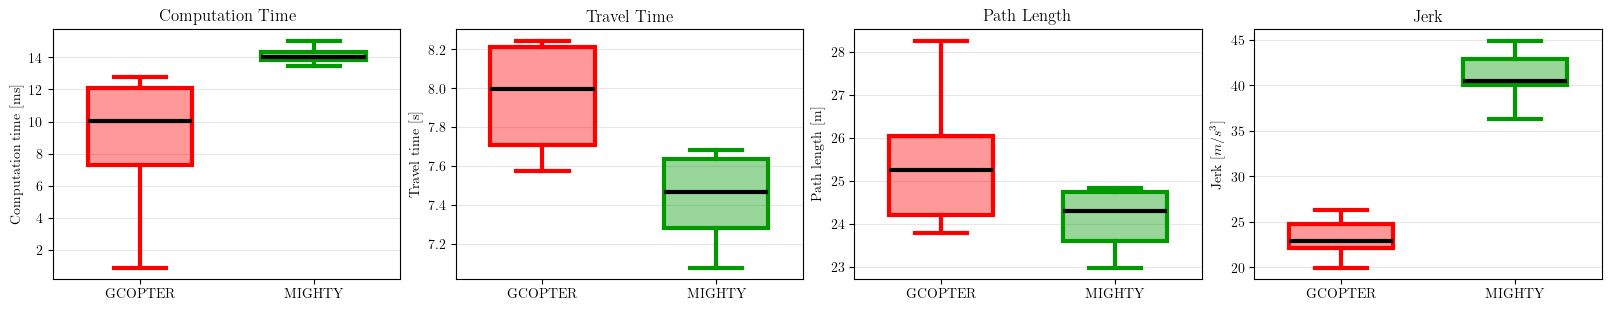

Comparing GCOPTER vs MINCO

Best single run (largest GCOPTER - OTHER travel-time gap):
  case: case_00000_v4.00_jw1e0
  goal: goal_005
  GCOPTER travel: 7.750 s
  MINCO travel: 6.437 s
  Δ travel time (GC - MINCO): 1.313 s (positive => MINCO faster)

Best CASE by max improvement over its goals:
  case: case_00000_v4.00_jw1e0
  max Δ travel time (GC - MINCO): 1.313 s

Top 5 single runs by improvement:


,case,goal,gc_travel_s,other_travel_s,delta_s
5,case_00000_v4.00_jw1e0,goal_005,7.750309,6.437282,1.313027
8,case_00000_v4.00_jw1e0,goal_008,8.244067,7.494120,0.749947
3,case_00000_v4.00_jw1e0,goal_003,8.107517,7.434776,0.672741
2,case_00000_v4.00_jw1e0,goal_002,8.110382,7.507057,0.603325
0,case_00000_v4.00_jw1e0,goal_000,7.664253,7.077726,0.586527



Best case path: /media/kkondo/lucas_pro/mighty_gcopter_bench/simple_bench/case_00000_v4.00_jw1e0/goal_005
GCOPTER CSV: /media/kkondo/lucas_pro/mighty_gcopter_bench/simple_bench/case_00000_v4.00_jw1e0/goal_005/gcopter_vaj.csv
MIGHTY  CSV: /media/kkondo/lucas_pro/mighty_gcopter_bench/simple_bench/case_00000_v4.00_jw1e0/goal_005/mighty_vaj.csv


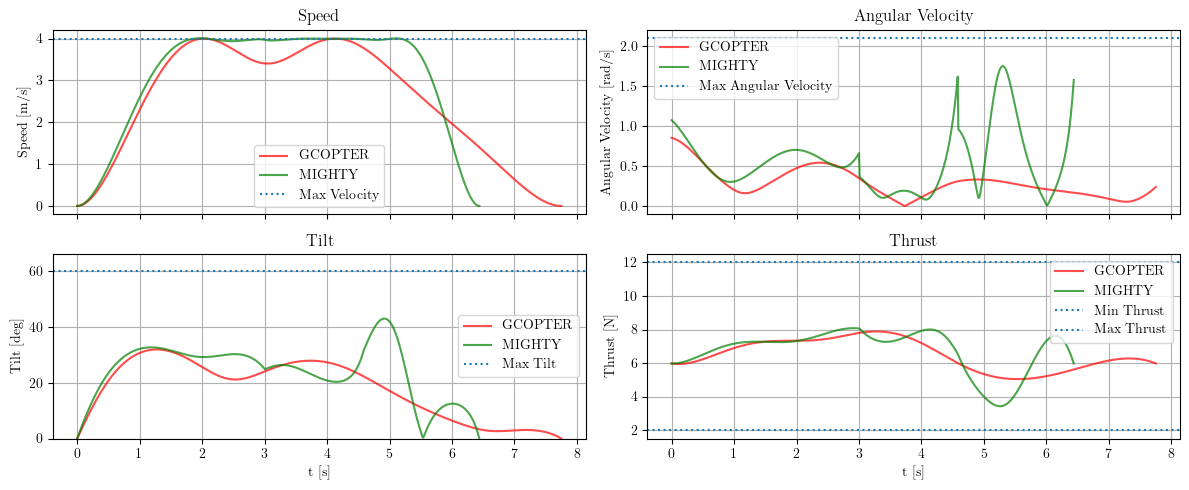

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Path to your aggregated CSV ===
# Change this to your actual file path:
CSV_PATH = "/media/kkondo/lucas_pro/mighty_gcopter_bench/simple_bench/analysis_summary/goal_summary.csv"   # e.g., "/media/kkondo/lucas_pro/mighty_gcopter_bench/goal_summary.csv"

# === Load CSV (first row is header) ===
df = pd.read_csv(CSV_PATH)

if True:

    # We will index by Excel letters (0-based indices):
    # A=0, B=1, P=15, Q=16, R=17, S=18, V=21, W=22, X=23, Y=24
    col_idx = {
        "case": 0,     # A
        "goal": 1,     # B
        "gc_solve_ms": 15,  # P
        "gc_travel_s": 16,  # Q
        "gc_path_m":   17,  # R
        "gc_jerk":     18,  # S
        "mi_solve_ms": 21,  # V  (MIGHTY)
        "mi_travel_s": 22,  # W
        "mi_path_m":   23,  # X
        "mi_jerk":     24,  # Y
    }

    # Select and rename
    use = df.iloc[:, list(col_idx.values())].copy()
    use.columns = list(col_idx.keys())

    # Ensure numeric types (coerce errors to NaN)
    for k in ["gc_solve_ms","gc_travel_s","gc_path_m","gc_jerk",
            "mi_solve_ms","mi_travel_s","mi_path_m","mi_jerk"]:
        use[k] = pd.to_numeric(use[k], errors="coerce")

    # print("Rows loaded:", len(use))
    # print(use.head())
    def _two_box(ax, a, b, ylabel, title, labels=("GCOPTER","MIGHTY")):
        a = pd.to_numeric(a, errors="coerce").dropna().values
        b = pd.to_numeric(b, errors="coerce").dropna().values

        # Colors (fill colors with alpha); use opaque edges for crisp outlines
        gc_fill = (1.0, 0.0, 0.0, 0.4)   # red, alpha=0.7
        mi_fill = (0.0, 0.6, 0.0, 0.4)   # green, alpha=0.7
        gc_edge = (1.0, 0.0, 0.0, 1.0)
        mi_edge = (0.0, 0.6, 0.0, 1.0)
        lw = 3.0  # line width

        # GCOPTER box
        bp1 = ax.boxplot(
            a, positions=[1], widths=0.6, vert=True, patch_artist=True, showfliers=False,
            boxprops=dict(linewidth=lw, edgecolor=gc_edge),
            whiskerprops=dict(linewidth=lw, color=gc_edge),
            capprops=dict(linewidth=lw, color=gc_edge),
            medianprops=dict(linewidth=lw, color="black")
        )
        for patch in bp1["boxes"]:
            patch.set_facecolor(gc_fill)

        # MIGHTY box
        bp2 = ax.boxplot(
            b, positions=[2], widths=0.6, vert=True, patch_artist=True, showfliers=False,
            boxprops=dict(linewidth=lw, edgecolor=mi_edge),
            whiskerprops=dict(linewidth=lw, color=mi_edge),
            capprops=dict(linewidth=lw, color=mi_edge),
            medianprops=dict(linewidth=lw, color="black")
        )
        for patch in bp2["boxes"]:
            patch.set_facecolor(mi_fill)

        ax.set_xticks([1, 2], labels)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(alpha=0.3, axis='y')
    # ---- build the 1x4 figure ----
    fig, axs = plt.subplots(1, 4, figsize=(16, 3), constrained_layout=True)

    _two_box(axs[0],
            use["gc_solve_ms"], use["mi_solve_ms"],
            ylabel="Computation time [ms]", title="Computation Time")

    _two_box(axs[1],
            use["gc_travel_s"], use["mi_travel_s"],
            ylabel="Travel time [s]", title="Travel Time")

    _two_box(axs[2],
            use["gc_path_m"], use["mi_path_m"],
            ylabel="Path length [m]", title="Path Length")

    _two_box(axs[3],
            use["gc_jerk"], use["mi_jerk"],
            ylabel=r"Jerk [$m/s^3$]", title="Jerk")

    plt.show()

    # ---------- load & slice by Excel-letter indices ----------
    # A=0, B=1, Q=16 (GC travel s), W=22 (MINCO travel s) -- MIGHTY travel s not given by letter, so we'll check by name later.
    df_full = pd.read_csv(CSV_PATH)


    # Build a small working frame using the letters you specified
    use = pd.DataFrame({
        "case": df_full.iloc[:, 0],   # A
        "goal": df_full.iloc[:, 1],   # B
        "gc_travel_s": pd.to_numeric(df_full.iloc[:, 16], errors="coerce"),  # Q
    })

    # Try to locate MIGHTY travel time column by common names first; else fall back to MINCO (W=22)
    # If your summary actually stores MIGHTY under a named column, add it here:
    known_mighty_names = ["my_travel_s", "mighty_travel_s", "mighty_time_s", "mighty_traj_time"]
    mighty_col = next((c for c in df_full.columns if c in known_mighty_names), None)

    if mighty_col is not None:
        OTHER_LABEL = "MIGHTY"
        use["other_travel_s"] = pd.to_numeric(df_full[mighty_col], errors="coerce")
    else:
        # Fall back to MINCO (W column index 22)
        OTHER_LABEL = "MINCO"
        use["other_travel_s"] = pd.to_numeric(df_full.iloc[:, 22], errors="coerce")  # W

    print(f"Comparing GCOPTER vs {OTHER_LABEL}")

    # ---------- compute delta and find best ----------
    use = use.dropna(subset=["gc_travel_s","other_travel_s"]).copy()
    use["delta_s"] = use["gc_travel_s"] - use["other_travel_s"]  # positive => OTHER is faster than GCOPTER

    # Best (case, goal) row where OTHER beats GCOPTER
    faster = use[use["delta_s"] > 0]
    if faster.empty:
        print("No rows where OTHER (MIGHTY/MINCO) is faster than GCOPTER.")
    else:
        best_row = faster.sort_values("delta_s", ascending=False).iloc[0]
        print("\nBest single run (largest GCOPTER - OTHER travel-time gap):")
        print(f"  case: {best_row['case']}")
        print(f"  goal: {best_row['goal']}")
        print(f"  GCOPTER travel: {best_row['gc_travel_s']:.3f} s")
        print(f"  {OTHER_LABEL} travel: {best_row['other_travel_s']:.3f} s")
        print(f"  Δ travel time (GC - {OTHER_LABEL}): {best_row['delta_s']:.3f} s (positive => {OTHER_LABEL} faster)")

        # Also identify which *case* is best when aggregating by MAX improvement within that case
        per_case = faster.groupby("case", as_index=False)["delta_s"].max().sort_values("delta_s", ascending=False)
        best_case = per_case.iloc[0]
        print("\nBest CASE by max improvement over its goals:")
        print(f"  case: {best_case['case']}")
        print(f"  max Δ travel time (GC - {OTHER_LABEL}): {best_case['delta_s']:.3f} s")

        # (Optional) show top 5 rows for sanity
        print("\nTop 5 single runs by improvement:")
        display(faster.sort_values("delta_s", ascending=False).head(5))

        # Get the best case's path
        best_case_goals = "/media/kkondo/lucas_pro/mighty_gcopter_bench/simple_bench/" + best_case['case'] + "/" + faster.sort_values("delta_s", ascending=False).head(1)['goal'].values[0]

        print(f"\nBest case path: {best_case_goals}")

        plot_history(best_case_goals, max_vel=max_vel)
